# K-means clustering

In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 
from sklearn.datasets import make_blobs 
%matplotlib inline 

In [5]:
x,y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [ ]:
x.shape

(1000, 2)

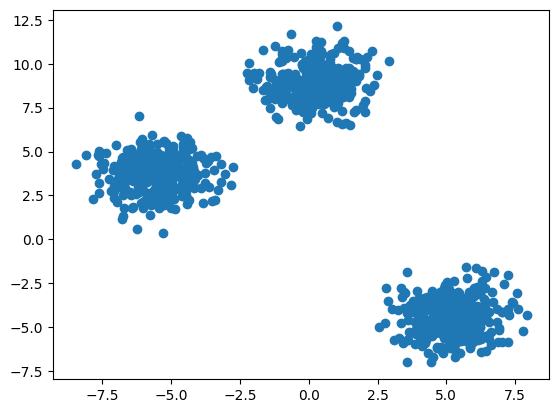

In [7]:
plt.scatter(x[:,0], x[:,1])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(x, test_size=0.33, random_state=42)
# y_train, y_test = train_test_split(y, test_size=0.33, random_state=42)

In [9]:
wcss =[]
for k in range(1,11):
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)    

In [10]:
wcss

[34827.57682552021,
 7935.437286145418,
 1319.2730531585612,
 1140.4677884655125,
 1035.6336387378697,
 870.5132039119201,
 766.4222533603231,
 663.7491741831369,
 580.7349812961102,
 549.0271296340708]

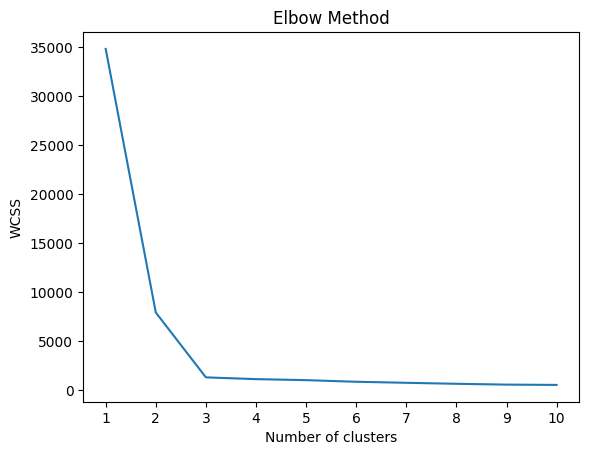

In [12]:
plt.plot(range(1,11), wcss)
plt.title('Elbow Method')   
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [21]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [22]:
y_labels= kmeans.fit_predict(x_train)

In [23]:
y_test_labels= kmeans.predict(x_test)

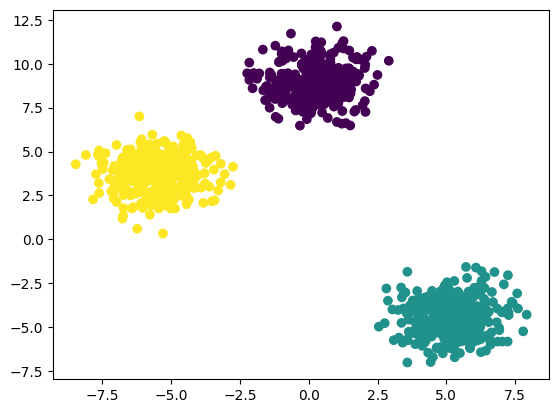

In [24]:
plt.scatter(x[:,0], x[:,1], c=y)

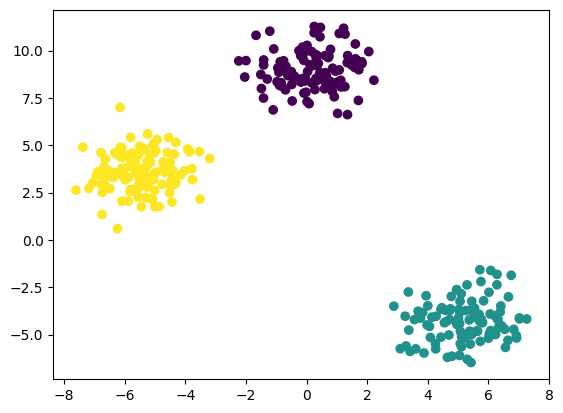

In [25]:
plt.scatter(x_test[:,0], x_test[:,1], c=y_test_labels)

In [26]:
!pip install kneed

In [27]:
from kneed import KneeLocator

In [28]:
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
kl.elbow

np.int64(3)

In [32]:
from sklearn.metrics import silhouette_score   


In [33]:
silhouette_coefficient= []
for k in range(2,11):
    k = KMeans(n_clusters=k, init='k-means++')
    k.fit(x_train)
    score = silhouette_score(x_train, k.labels_)
    silhouette_coefficient.append(score)

In [34]:
silhouette_coefficient

[0.7281443868598331,
 0.8071181203797672,
 0.6578773435536361,
 0.4732813372370851,
 0.2971232925584101,
 0.327003641501031,
 0.3500868639211379,
 0.3320072056982517,
 0.3383292911837021]

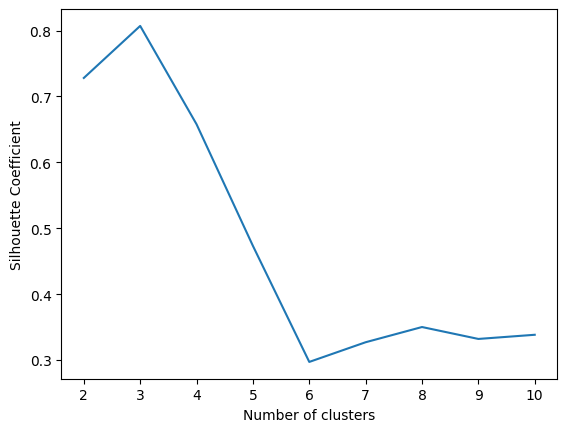

In [35]:
plt.plot(range(2,11), silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()